In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from geoai.utils_ds.DataFrameOps import DataFrameOperations
from geoai.utils_ds.ModelOps import AccuracyOperations, PreProcessingOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
df_ops = DataFrameOperations()
vis_ops = VisualizeOperations()
pre_ops = PreProcessingOperations()
acc_ops = AccuracyOperations()

In [4]:
X_train = pd.read_csv("csv_files/X_train_with_indices.csv")
X_val = pd.read_csv("csv_files/X_val_with_indices.csv")
X_test = pd.read_csv("csv_files/X_test_with_indices.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_val = pd.read_csv("csv_files/y_val.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI
0,1640.5,1671.6,1837.5,1918.3334,2692.8333,0.021522,0.167962,0.000088


In [5]:
# scale the data
X_train_scaled, X_val_scaled, X_test_scaled = pre_ops.scale_to_minmax(X_train, X_val, X_test)

In [6]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_scaled)
y_pred_val = lr.predict(X_val_scaled)
y_pred_test = lr.predict(X_test_scaled)

In [7]:
# calculate the accuracy
print(f"Train Accuracy: {acc_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Validation Accuracy: {acc_ops.calculate_classification_accuracy(y_val, y_pred_val)}")
print(f"Test Accuracy: {acc_ops.calculate_classification_accuracy(y_test, y_pred_test)}")


Train Accuracy: (0.9157894736842105, 0.9181689113097821, 0.9157894736842105, 0.9162674510251376)
Validation Accuracy: (0.9074380165289256, 0.9100444913529891, 0.9074380165289256, 0.9079203674258673)
Test Accuracy: (0.8925619834710744, 0.8965783250186733, 0.8925619834710744, 0.8934683184491714)


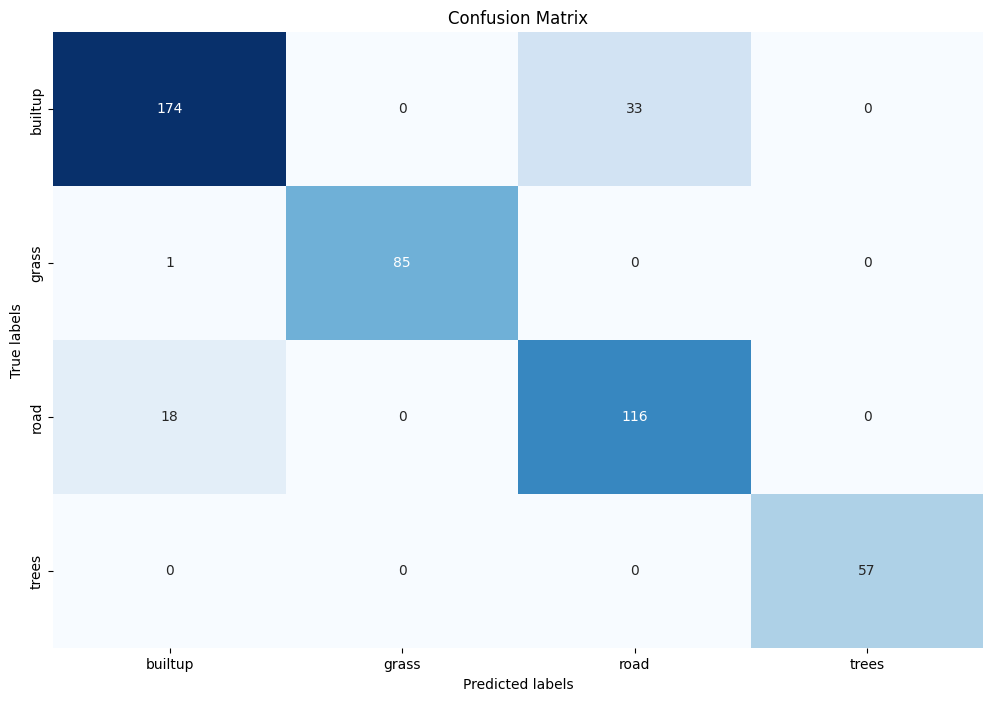

<Figure size 640x480 with 0 Axes>

In [8]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)

# Use the data with Feature Engineering

In [10]:
X_train_fe = pd.read_csv("csv_files/X_train_preprocessed.csv")
X_val_fe = pd.read_csv("csv_files/X_val_preprocessed.csv")
X_test_fe = pd.read_csv("csv_files/X_test_preprocessed.csv")
X_train_fe.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,0.335787,0.310045,0.375764,0.269771,0.304883,0.060522,0.739402,0.033387,0.144491,0.139798,...,0.046334,0.000684,0.853833,0.003242,0.264803,0.691283,0.001107,1,0,0
